# Opportunity Scoring – Exploratory Analysis

Builds the scoring/confidence design from `docs/decisions/0005-opoprtunity-scoring-methodology.md` step by step. 
Running example: **frozen tongues (NCM 02062100) - Vietnam**.

In [3]:
from pathlib import Path

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = Path("data/processed/comexstat.duckdb")
con = duckdb.connect(str(DB_PATH), read_only=True)

## Step 0 – Look at the raw numbers first

Before fitting anything, let's just see what we're working with. 

In [5]:
yearly = con.execute("""
    SELECT
        year,
        SUM(fob_usd) AS fob_usd,
        SUM(kg) AS kg,
    FROM marts.exports
    WHERE ncm_code = '02062100'
        AND country = 'Vietnam'
    GROUP BY year
    ORDER BY year
""").df()

yearly

,year,fob_usd,kg
0,2009,67537.0,30144.0
1,2012,62383.0,23541.0
2,2015,426587.0,290962.0
3,2016,253919.0,170882.0
4,2017,178302.0,120192.0
5,2018,15707.0,8828.0
6,2019,135416.0,61163.0
7,2020,89158.0,46224.0
8,2021,137.0,20.0
9,2022,6784.0,3074.0


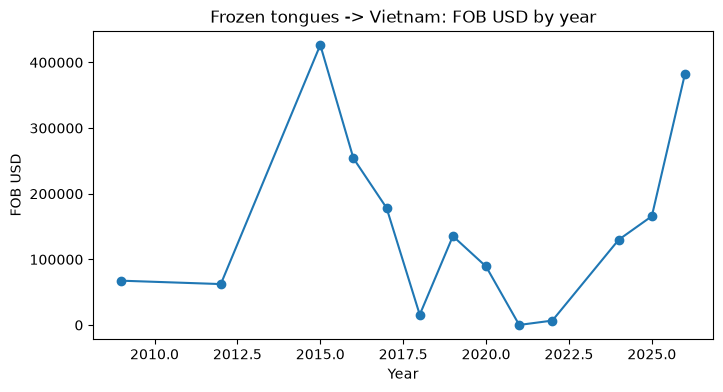

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(yearly["year"], yearly["fob_usd"], marker="o")
ax.set_title("Frozen tongues -> Vietnam: FOB USD by year")
ax.set_xlabel("Year")
ax.set_ylabel("FOB USD")
plt.show()

## Step 1: fit the trend (ADR 0005)

Trailing  10-year window, log-linear regression via DuckDB's built-in `regr_slope` / `regr_r2` / `regr_intercept` aggregates.

In [16]:
import math

WINDOW_YEARS = 10

max_year = con.execute("SELECT max(year) FROM marts.exports").fetchone()[0]
min_year = max_year - WINDOW_YEARS + 1
print(f"Trailing window: {min_year} – {max_year}")

trend = con.execute(f"""
    WITH vietnam_selection AS (
        SELECT
            year,
            sum(fob_usd) AS fob_usd
        FROM marts.exports
        WHERE ncm_code = '02062100'
            AND country = 'Vietnam'
            AND year BETWEEN {min_year} AND {max_year}
        GROUP BY year  
    )
    SELECT
        regr_slope(ln(fob_usd), year)       AS log_growth_rate,
        regr_r2(ln(fob_usd), year)          AS trend_r2,
        regr_intercept(ln(fob_usd), year)   AS log_intercept,
        count(*)                            AS years_active
    FROM vietnam_selection
    WHERE fob_usd > 0
""").df()

log_growth_rate = trend.loc[0, "log_growth_rate"]
trend_r2 = trend.loc[0, "trend_r2"]
years_active = trend.loc[0, "years_active"]
annual_growth_pct = math.exp(log_growth_rate) - 1

print(f"annual growth rate:     {annual_growth_pct:.1%}")
print(f"trend R²:               {trend_r2:.2f}")
print(f"years active:           {years_active} / {WINDOW_YEARS}")

Trailing window: 2017 – 2026
annual growth rate:     16.7%
trend R²:               0.04
years active:           9 / 10


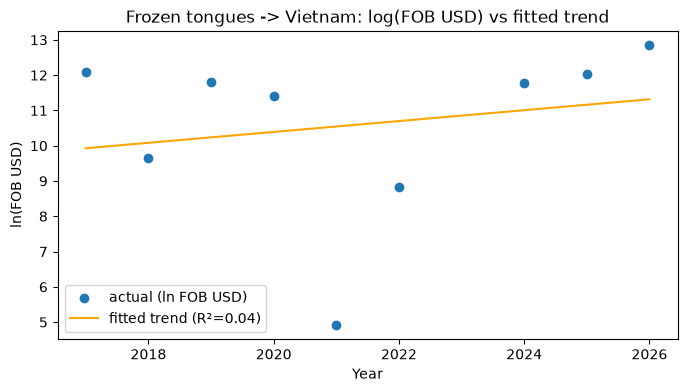

In [19]:
windowed = con.execute(f"""
    SELECT year, sum(fob_usd) AS fob_usd
    FROM marts.exports
        WHERE ncm_code = '02062100'
        AND country = 'Vietnam'
        AND year BETWEEN {min_year} AND {max_year}
    GROUP BY year
    ORDER BY year  
""").df()

windowed = windowed[windowed["fob_usd"] > 0].copy()
windowed["ln_fob_usd"] = windowed["fob_usd"].apply(math.log)

log_intercept = trend.loc[0, "log_intercept"]
fitted = log_intercept + log_growth_rate * windowed["year"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(windowed["year"], windowed["ln_fob_usd"], label="actual (ln FOB USD)")
ax.plot(windowed["year"], fitted, color="orange", label=f"fitted trend (R²={trend_r2:.2f})")
ax.set_title("Frozen tongues -> Vietnam: log(FOB USD) vs fitted trend")
ax.set_xlabel("Year")
ax.set_ylabel("ln(FOB USD)")
ax.legend()
plt.show()

## Step 2: coverage and volume confidence, then combine all three into the overall confidence number from ADR 0005.

- `coverage_score` = years with actual trade / window size (capped at 1).
- `volume_confidence` = total_fob_usd / (total_fob_usd + K), where K is the *median* window-total across all (ncm_code, country) pairs – data derived, not a fiexed dollar figure.

In [20]:
coverage_score = min(years_active / WINDOW_YEARS, 1.0)
total_fob_usd = windowed["fob_usd"].sum()

In [23]:
group_totals = con.execute(f"""
    SELECT
        ncm_code,
        country,
        sum(fob_usd) AS total_fob_usd
    FROM marts.exports
    WHERE year BETWEEN {min_year} AND {max_year}
    GROUP BY ncm_code, country
    HAVING sum(fob_usd) > 0
""").df()

K = group_totals["total_fob_usd"].median()
print(f"K (median group total , {min_year} – {max_year}): ${K:.0f}")
print(f"number of (ncm_code, country) groups: {len(group_totals)}")

K (median group total , 2017 – 2026): $49736
number of (ncm_code, country) groups: 1253


In [24]:
volume_confidence = total_fob_usd / (total_fob_usd + K)
confidence = (coverage_score * trend_r2 * volume_confidence) ** (1 / 3)

print(f"coverage_score:             {coverage_score:.2f}")
print(f"trend R²:                   {trend_r2:.2f}")
print(f"volume confidence           {volume_confidence:.2f}")
print()
print(f"CONFIDENCE:                 {confidence:.2f}")

coverage_score:             0.90
trend R²:                   0.04
volume confidence           0.96

CONFIDENCE:                 0.32


## Step 3: *share_pct* and the **opportunity_score**

`share_pct` = this country's `fob_usd / total fob_usd` across all countries, for this product, in the most recent year (proeduct-fixed lens).

`opportunity_score` = `annual_growth_pct x (1 - share_pct)` 

In [28]:
recent_year_totals = con.execute(f"""
    SELECT country, sum(fob_usd) AS fob_usd
    FROM marts.exports
    WHERE ncm_code = '02062100'
        AND year = {max_year}
    GROUP BY country
""").df()

total_product_fob = recent_year_totals["fob_usd"].sum()
vietnam_row = recent_year_totals.loc[recent_year_totals["country"] == "Vietnam", "fob_usd"]
vietnam_fob = vietnam_row.iloc[0] if not vietnam_row.empty else 0.0

share_pct = vietnam_fob / total_product_fob if total_product_fob else 0.0

print(f"Vietnam's share of Brazil's {max_year} frozen-tongue exports: {share_pct:.1%}")

Vietnam's share of Brazil's 2026 frozen-tongue exports: 0.9%


In [29]:
opportunity_score = annual_growth_pct * (1 - share_pct)

print(f"annual growth pct:      {annual_growth_pct:.1%}")
print(f"share pct:              {share_pct:.1%}")
print(f"OPPORTUNITY SCORE:      {opportunity_score:.3f}")
print(f"CONFIDENCE              {confidence:.2f}")

annual growth pct:      16.7%
share pct:              0.9%
OPPORTUNITY SCORE:      0.165
CONFIDENCE              0.32


## Step 3: generalize across every country (still using frozen tongues)

Same regression fit as before, but grouped by country instead of harcoded to Vietnam. Reuses `K`, `WINDOW_YEARS`, `min_year`, `max_year` from the single-pair example.

In [32]:
sql = f"""
    WITH windowed AS (
        SELECT country, year, sum(fob_usd) AS fob_usd
        FROM marts.exports
        WHERE ncm_code = '02062100'
            AND year BETWEEN {min_year} AND {max_year}
        GROUP BY country, year,
        HAVING sum(fob_usd) > 0
    ),
    trend AS(
        SELECT
            country,
            regr_slope(ln(fob_usd), year)   AS log_growth_rate,
            regr_r2(ln(fob_usd), year)      AS trend_r2,
            count(*)                        AS years_active,
            sum(fob_usd)                    AS total_fob_usd
        FROM windowed
        GROUP BY country
    ),
    recent AS(
        SELECT country, sum(fob_usd) AS fob_usd
        FROM marts.exports
        WHERE ncm_code = '02062100'
            AND year = {max_year}
        GROUP BY country
    )
    SELECT
        t.country, t.log_growth_rate, t.trend_r2, t.years_active,
        t.total_fob_usd, r.fob_usd AS recent_fob_usd
    FROM trend t
    LEFT JOIN recent r ON r.country = t.country
"""

countries = con.execute(sql).df()
countries = countries[countries["years_active"] >= 2].copy() # we need at least 2 points for a line

countries["annual_growth_pct"] = countries["log_growth_rate"].apply(lambda s: math.exp(s) - 1)
countries["coverage_score"] = (countries["years_active"] / WINDOW_YEARS).clip(upper=1.0)
countries["volume_confidence"] = countries["total_fob_usd"] / (countries["total_fob_usd"] + K)
countries["trend_r2"] = countries["trend_r2"].fillna(0)
countries["confidence"] = (
    countries["coverage_score"] * countries["trend_r2"] * countries["volume_confidence"]
) ** (1 / 3)

total_recent = countries["recent_fob_usd"].fillna(0).sum()
countries["share_pct"] = countries["recent_fob_usd"].fillna(0) / total_recent
countries["opportunity_score"] = countries["annual_growth_pct"] * (1 - countries["share_pct"])

ranked = countries.sort_values("opportunity_score", ascending=False)
ranked[["country", "annual_growth_pct", "share_pct", "opportunity_score", "confidence"]].head(15)


,country,annual_growth_pct,share_pct,opportunity_score,confidence
14,Jordan,1431.671053,0.002514,1428.071286,0.515913
32,Chile,117.255198,0.001445,117.085812,0.481788
33,Sierra Leone,81.715763,0.006162,81.212241,0.552421
87,Italy,4.894752,0.000000,4.894752,0.313425
85,Poland,4.574074,0.000000,4.574074,0.112331
107,Morocco,4.196688,0.000000,4.196688,0.520187
105,Bosnia and Herzegovina,3.842105,0.000000,3.842105,0.076367
61,Cambodia,1.950886,0.009059,1.933212,0.701547
41,Philippines,1.963778,0.018785,1.926888,0.762787
79,Papua New Guinea,1.747572,0.000000,1.747572,0.557918


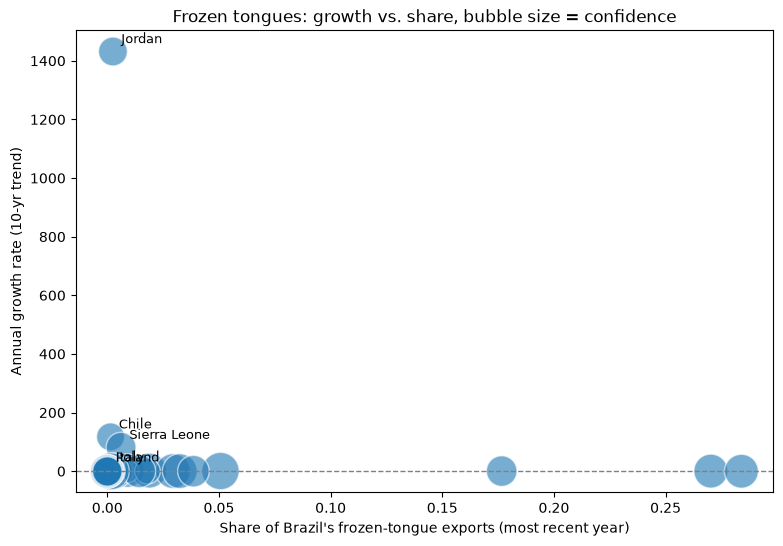

In [34]:
fig, ax = plt.subplots(figsize=(9, 6))
sizes = ranked["confidence"] * 800 + 20

ax.scatter(ranked["share_pct"], ranked["annual_growth_pct"], s=sizes, alpha=0.6, edgecolor="white")

for _, row in ranked.head(5).iterrows():
    ax.annotate(row["country"], (row["share_pct"], row["annual_growth_pct"]),
                textcoords="offset points", xytext=(6, 6), fontsize=9)

ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.set_xlabel("Share of Brazil's frozen-tongue exports (most recent year)")
ax.set_ylabel("Annual growth rate (10-yr trend)")
ax.set_title("Frozen tongues: growth vs. share, bubble size = confidence")
plt.show()

In [36]:
ranked[["country", "years_active", "trend_r2", "log_growth_rate", "total_fob_usd", "confidence"]].head(10)

,country,years_active,trend_r2,log_growth_rate,total_fob_usd,confidence
14,Jordan,2,1.000000,7.267296,108959.0,0.515913
32,Chile,2,1.000000,4.772845,63086.0,0.481788
33,Sierra Leone,2,1.000000,4.415410,266873.0,0.552421
87,Italy,3,0.954085,1.774062,5995.0,0.313425
85,Poland,2,1.000000,1.718126,355.0,0.112331
107,Morocco,2,1.000000,1.648021,118177.0,0.520187
105,Bosnia and Herzegovina,2,1.000000,1.577350,111.0,0.076367
61,Cambodia,4,0.957428,1.082105,455607.0,0.701547
41,Philippines,7,0.670401,1.086465,867069.0,0.762787
79,Papua New Guinea,2,1.000000,1.010718,327980.0,0.557918


## Finding R² is not a reliable consistency signal at low samples

Sorting by `opportunity_score` put Jordan, Chile, and Sierra Leone at the top – anual growth rates over 1,400% that turned out to be statistical artifacts, not real trends.

Root cause: every row with `years_active = 2` whos `trend_r2 = 1.0000` exactly. This is not a coincidence, as a straight line through exactly 2 points always fits perfectly, so R² always equals 1.0 regardless of what these points represent. Only when there are more data points that it starts to carry real information.

**Fix:**
1. Raise the minimum `years_active` flor from 2 to **4** – bwlow that, a trend can't be assessed at all (adjusted R² is undefined at n=2, still too unstable at n=3).
2. Replace raw `trend_r2` with **adjusted R²**, which explicitly penalizes small sample sizes:

`adj_r2 = 1 - (1 - r2) / (n - 2)`

(clipped to `[0, 1]`) – a poor fit can push this negative, which we treat as zero confidence instead of a negative one.

In [39]:
MIN_YEARS_ACTIVE = 4

countries = con.execute(sql).df()
countries = countries[countries["years_active"] >= MIN_YEARS_ACTIVE].copy() # we need at least 2 points for a line

countries["annual_growth_pct"] = countries["log_growth_rate"].apply(lambda s: math.exp(s) - 1)
countries["coverage_score"] = (countries["years_active"] / WINDOW_YEARS).clip(upper=1.0)
countries["volume_confidence"] = countries["total_fob_usd"] / (countries["total_fob_usd"] + K)

n = countries["years_active"]
r2 = countries["trend_r2"].fillna(0)
countries["trend_r2_adj"] = (1 - (1- r2) * (n - 1) / (n - 2)).clip(lower=0, upper=1)
countries["confidence"] = (
    countries["coverage_score"] * countries["trend_r2_adj"] * countries["volume_confidence"]
) ** (1 / 3)

total_recent = countries["recent_fob_usd"].fillna(0).sum()
countries["share_pct"] = countries["recent_fob_usd"].fillna(0) / total_recent
countries["opportunity_score"] = countries["annual_growth_pct"] * (1 - countries["share_pct"])

ranked = countries.sort_values("opportunity_score", ascending=False)
ranked[["country","years_active", "trend_r2", "trend_r2_adj",
        "annual_growth_pct", "share_pct", "opportunity_score", "confidence"]].head(15)

,country,years_active,trend_r2,trend_r2_adj,annual_growth_pct,share_pct,opportunity_score,confidence
46,Cambodia,4,0.957428,0.936143,1.950886,0.011158,1.929117,0.696309
61,Philippines,7,0.670401,0.604482,1.963778,0.023138,1.918341,0.736918
68,Ghana,4,0.825523,0.738284,1.374562,0.002591,1.371000,0.641432
97,Cayman Islands,5,0.425841,0.234455,1.160465,0.000000,1.160465,0.133612
119,Bhutan,4,0.606769,0.410153,0.923771,0.000000,0.923771,0.525534
6,Barbados,8,0.227144,0.098335,0.900896,0.000004,0.900893,0.408929
55,Singapore,9,0.495330,0.423234,0.690812,0.002893,0.688813,0.712338
22,Tunisia,6,0.979698,0.974622,0.662524,0.003202,0.660402,0.789355
85,Grenada,4,0.661952,0.492929,0.603926,0.000000,0.603926,0.321504
114,Angola,9,0.244795,0.136909,0.596503,0.000000,0.596503,0.477806


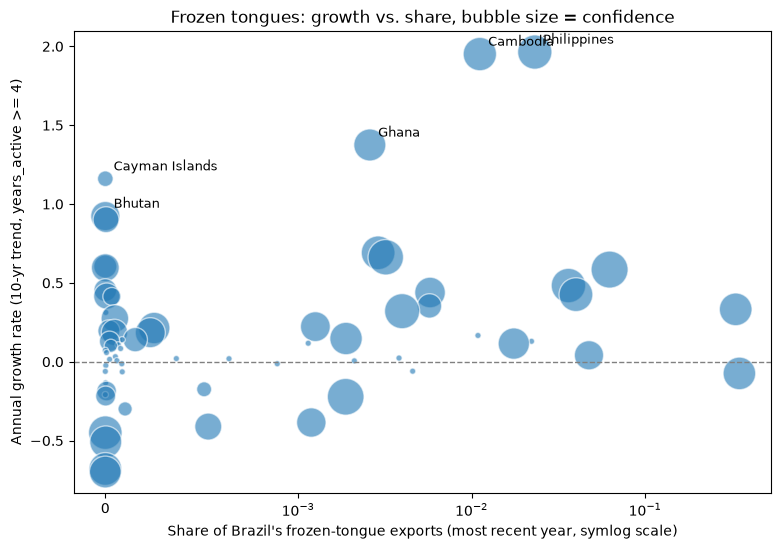

In [41]:
fig, ax = plt.subplots(figsize=(9, 6))
sizes = ranked["confidence"] * 800 + 20

ax.scatter(ranked["share_pct"], ranked["annual_growth_pct"], s=sizes, alpha=0.6, edgecolor="white")

for _, row in ranked.head(5).iterrows():
    ax.annotate(row["country"], (row["share_pct"], row["annual_growth_pct"]),
                textcoords="offset points", xytext=(6, 6), fontsize=9)

ax.set_xscale("symlog", linthresh=1e-3)
ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.set_xlabel("Share of Brazil's frozen-tongue exports (most recent year, symlog scale)")
ax.set_ylabel("Annual growth rate (10-yr trend, years_active >= 4)")
ax.set_title("Frozen tongues: growth vs. share, bubble size = confidence")
plt.show()